# Week 4 Quantum Computing 


## Learning outcomes
By the end of this notebook, students should be able to:

- Represent single- and multi-qubit systems using state vectors.
- Create superposition using the Hadamard gate.
- Generate and interpret Bell-state entanglement.
- Visualise quantum states using Bloch sphere, Q-sphere, and histograms.
- Export and import circuits using QASM.
- Understand how QASM can be submitted to a quantum device/simulator such as Quokka.
- Interpret output bitstrings and discuss randomness in quantum measurements.



## 1. State Vector Representation

This cell introduces the **state vector**, which is the mathematical representation of a quantum system. A two-qubit circuit is created, where:

- `H` gate is applied to qubit 0 to create superposition.
- `X` gate is applied to qubit 1 to flip it from \(|0
angle\) to \(|1
angle\).

The resulting state vector shows the amplitudes of possible basis states. The Bloch multivector visualisation helps students connect the mathematical state with a geometric representation.

**Class discussion:** Ask students what the Hadamard gate does to \(|0
angle\), and why the X gate changes the second qubit.


     ┌───┐
q_0: ┤ H ├
     ├───┤
q_1: ┤ X ├
     └───┘
Statevector([0.        +0.j, 0.        +0.j, 0.70710678+0.j,
             0.70710678+0.j],
            dims=(2, 2))


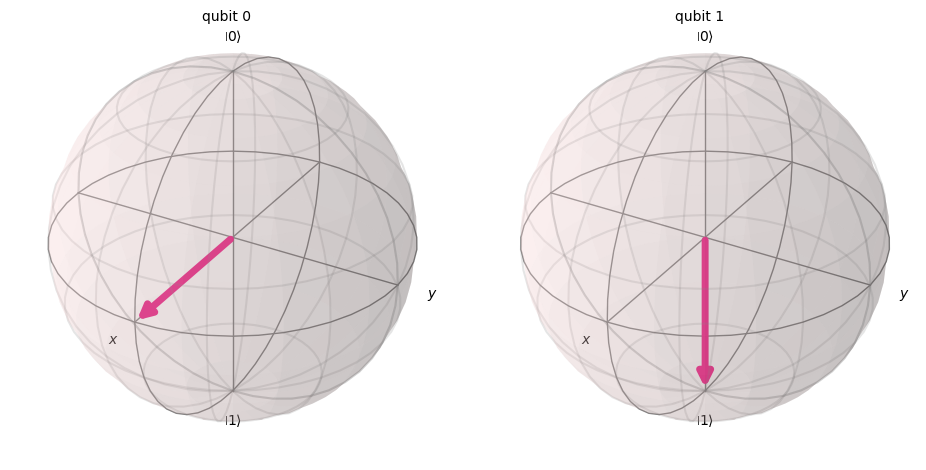

In [1]:
#1State Vector 
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
 
qc = QuantumCircuit(2)
qc.h(0)
qc.x(1)
print(qc)
state = Statevector(qc)
print(state)
plot_bloch_multivector(state)

## 2. Single-Qubit Superposition and Measurement

This activity demonstrates how a single qubit can be placed into superposition using the Hadamard gate. Before measurement, the qubit exists as a combination of \(|0
angle\) and \(|1
angle\). After measurement, the simulator returns classical outcomes.

The code calculates:

- the state vector,
- the probability of each state,
- measurement counts after 100 shots,
- a histogram of observed outcomes.

 The theoretical probabilities should be approximately 50% for \(|0
angle\) and 50% for \(|1
angle\), but the measured counts may vary due to randomness and finite shots.


Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))
Probabilities: [np.float64(0.4999999999999999), np.float64(0.4999999999999999)]
{'1': 50, '0': 50}
      ┌───┐┌─┐
  q0: ┤ H ├┤M├
      └───┘└╥┘
c0: 1/══════╩═
            0 


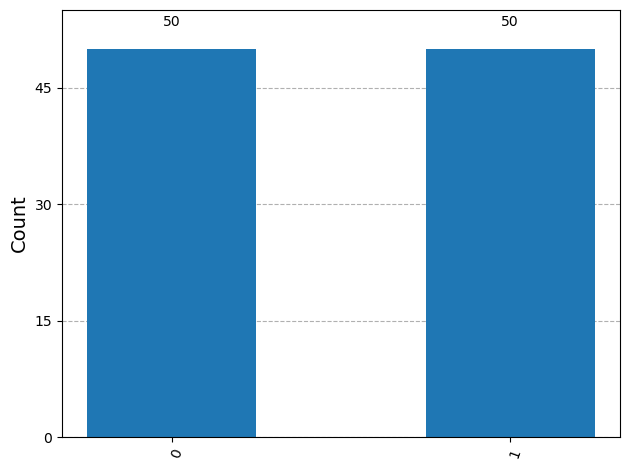

In [2]:
#Single Qubit
from qiskit import QuantumCircuit,  ClassicalRegister, QuantumRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

# Create a quantum register with 1 qubit
qr = QuantumRegister(1)

# Create a classical register with 1 bit
cr = ClassicalRegister(1)

# Create a quantum circuit
circuit = QuantumCircuit(qr,cr)

# Apply a Hadamard gate to generate a superposition of |0⟩ and |1⟩
circuit.h(qr[0])

state = Statevector(circuit)
print(state)
# Convert state vector to probabilities
probabilities = [abs(amplitude)**2 for amplitude in state]

# Print or visualize the probabilities
print("Probabilities:", probabilities)

# Measure the qubit and store the result in the classical register
circuit.measure(qr, cr)
# Choose the AerSimulator backend
simulator = AerSimulator()

# Simulate the circuit
job = simulator.run(circuit, shots=100)

# Get the result
result = job.result()

# Print the counts
print(result.get_counts(circuit))

# Visualize the circuit
print(circuit)

# Visualize the measurement outcomes
plot_histogram(result.get_counts(circuit))



## 3. Multiple-Qubit Superposition

This section extends the single-qubit idea to four qubits. A Hadamard gate is applied to each qubit, creating a uniform superposition across all possible 4-bit states.

With 4 qubits, there are \(2^4 = 16\) possible measurement outcomes. The histogram should show these outcomes distributed approximately evenly when the number of shots is limited.

This demonstrates why quantum systems scale exponentially: each additional qubit doubles the number of possible basis states.


{'0001': 7, '1001': 6, '1111': 6, '0111': 6, '1000': 7, '1110': 2, '0101': 7, '0010': 9, '1011': 8, '1100': 4, '0011': 5, '0100': 6, '0000': 12, '0110': 5, '1101': 6, '1010': 4}
      ┌───┐┌─┐         
q1_0: ┤ H ├┤M├─────────
      ├───┤└╥┘┌─┐      
q1_1: ┤ H ├─╫─┤M├──────
      ├───┤ ║ └╥┘┌─┐   
q1_2: ┤ H ├─╫──╫─┤M├───
      ├───┤ ║  ║ └╥┘┌─┐
q1_3: ┤ H ├─╫──╫──╫─┤M├
      └───┘ ║  ║  ║ └╥┘
c1: 4/══════╩══╩══╩══╩═
            0  1  2  3 


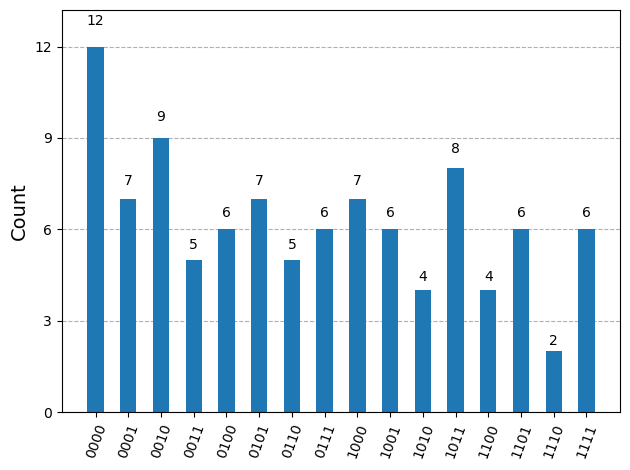

In [3]:
#Multiple Qubits
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import DensityMatrix

# Create a quantum register with 8 qubits
qr = QuantumRegister(4)

# Create a classical register with 8 bits
cr = ClassicalRegister(4)

# Create a quantum circuit
circuit = QuantumCircuit(qr, cr)

# Apply Hadamard gates to all qubits to generate a superposition of |0⟩ and |1⟩
for i in range(4):
    circuit.h(qr[i])

# Measure all qubits and store the results in the classical register
circuit.measure(qr, cr)

# Choose the AerSimulator backend
simulator = AerSimulator()

# Simulate the circuit
job = simulator.run(circuit, shots=100)

# Get the result
result = job.result()

# Print the counts
print(result.get_counts(circuit))

# Visualize the circuit
print(circuit)

# Visualize the measurement outcomes
plot_histogram(result.get_counts(circuit))


## 4. Bell-State Entanglement

This cell creates a Bell state using two gates:

- `H(0)` creates superposition on the first qubit.
- `CX(0, 1)` entangles the second qubit with the first.

The expected measurement results are mainly `00` and `11`, showing strong correlation between the qubits. This is a key demonstration of quantum entanglement.

 why `01` and `10` should not appear frequently in an ideal Bell-state circuit?


{'00': 41, '11': 59}
        ┌───┐      ░ ┌─┐   
   q_0: ┤ H ├──■───░─┤M├───
        └───┘┌─┴─┐ ░ └╥┘┌─┐
   q_1: ─────┤ X ├─░──╫─┤M├
             └───┘ ░  ║ └╥┘
meas: 2/══════════════╩══╩═
                      0  1 


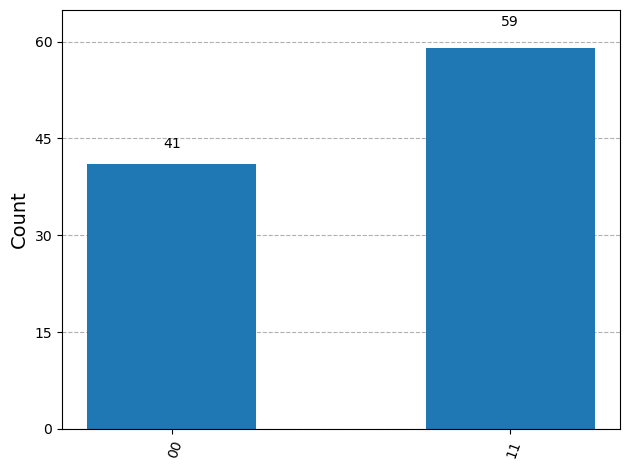

In [4]:
import numpy as np

# Import Qiskit
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_state_city
import qiskit.quantum_info as qi
simulator = AerSimulator()

# Create circuit
circ = QuantumCircuit(2)
circ.h(0)
circ.cx(0, 1)
circ.measure_all()

simulator = AerSimulator()
# Simulate the circuit
job = simulator.run(circ, shots=100)

# Get the result
result = job.result()

# Print the counts
print(result.get_counts(circ))

# Visualize the circuit
print(circ)

# Visualize the measurement outcomes
plot_histogram(result.get_counts(circ))


## Teaching pause: Review before moving to visualisations

Use this point to briefly review:

- state vector representation,
- measurement and histograms,
- superposition,
- entanglement.

The next cells focus more on visualising quantum states rather than only measuring them.


## 5. Q-Sphere Visualisation of a Bell State

This cell creates the Bell state again and visualises it using a Q-sphere. The Q-sphere provides a useful way to represent amplitudes and phases of multi-qubit quantum states.

For a Bell state, students should observe that only selected basis states have significant amplitude.

Q-sphere visualisation is especially useful for multi-qubit states, where Bloch sphere visualisation becomes less intuitive.


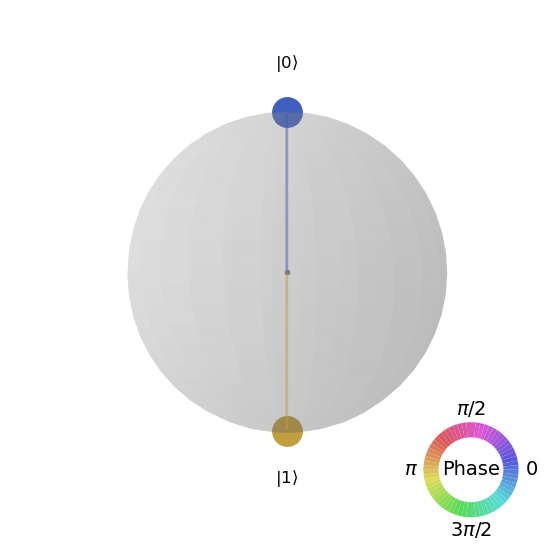

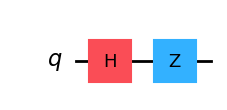

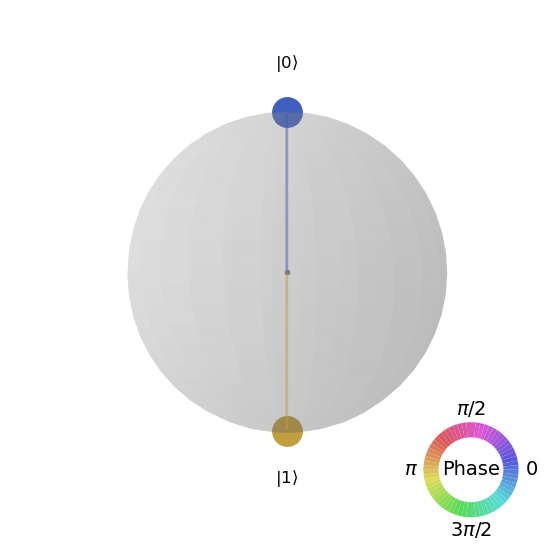

In [13]:
qc = QuantumCircuit(1)
qc.h(0)
qc.z(0)

qc.draw("mpl")
state = Statevector.from_instruction(qc)
plot_state_qsphere(state)

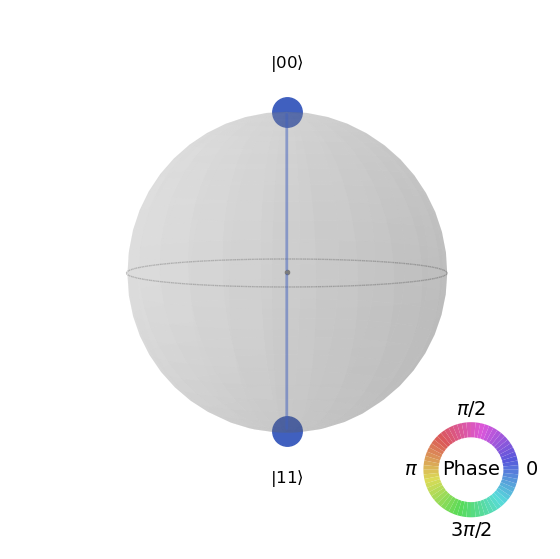

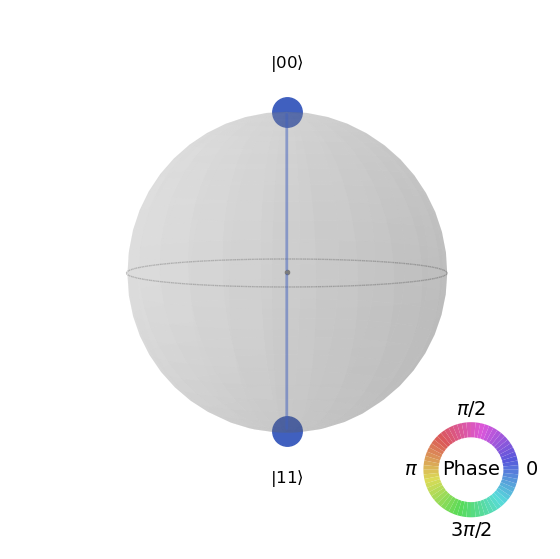

In [14]:
from math import pi
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.quantum_info import DensityMatrix
from qiskit.visualization import plot_state_city
from qiskit.visualization import plot_state_qsphere
from qiskit.visualization import plot_bloch_multivector
 
# Create a Bell state for demonstration
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
psi = Statevector(qc)
#psi.draw("latex")  # psi is a Statevector object
#DensityMatrix(psi).draw("latex")  # convert to a DensityMatrix and draw
#psi.draw("city")
psi.draw("qsphere")


## 6. Comparing a Non-Entangled Two-Qubit State

This cell creates another two-qubit state using `H(0)` and `X(1)`, but it does not use a controlled gate such as `CX`. Therefore, this state is not entangled in the same way as the Bell state.

Students can compare this output with the previous Bell-state output to understand the difference between:

- superposition, and
- entanglement.

 Superposition alone does not automatically mean entanglement.


     ┌───┐
q_0: ┤ H ├
     ├───┤
q_1: ┤ X ├
     └───┘
Statevector([0.        +0.j, 0.        +0.j, 0.70710678+0.j,
             0.70710678+0.j],
            dims=(2, 2))


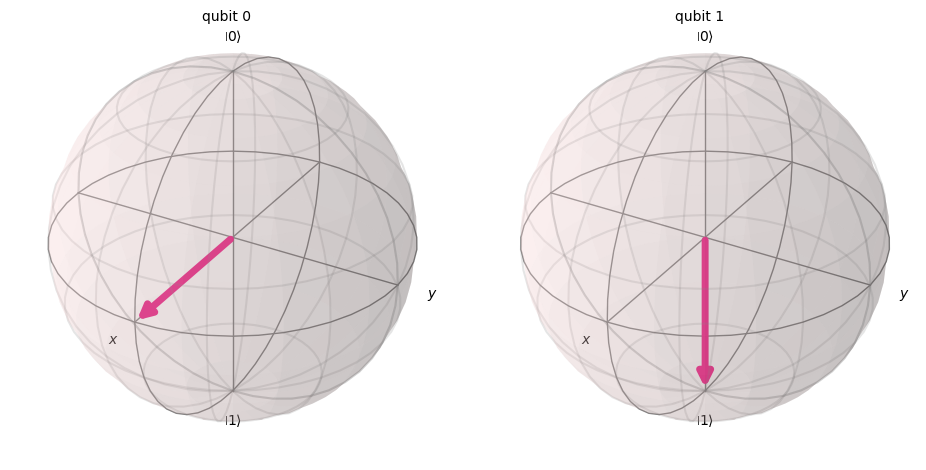

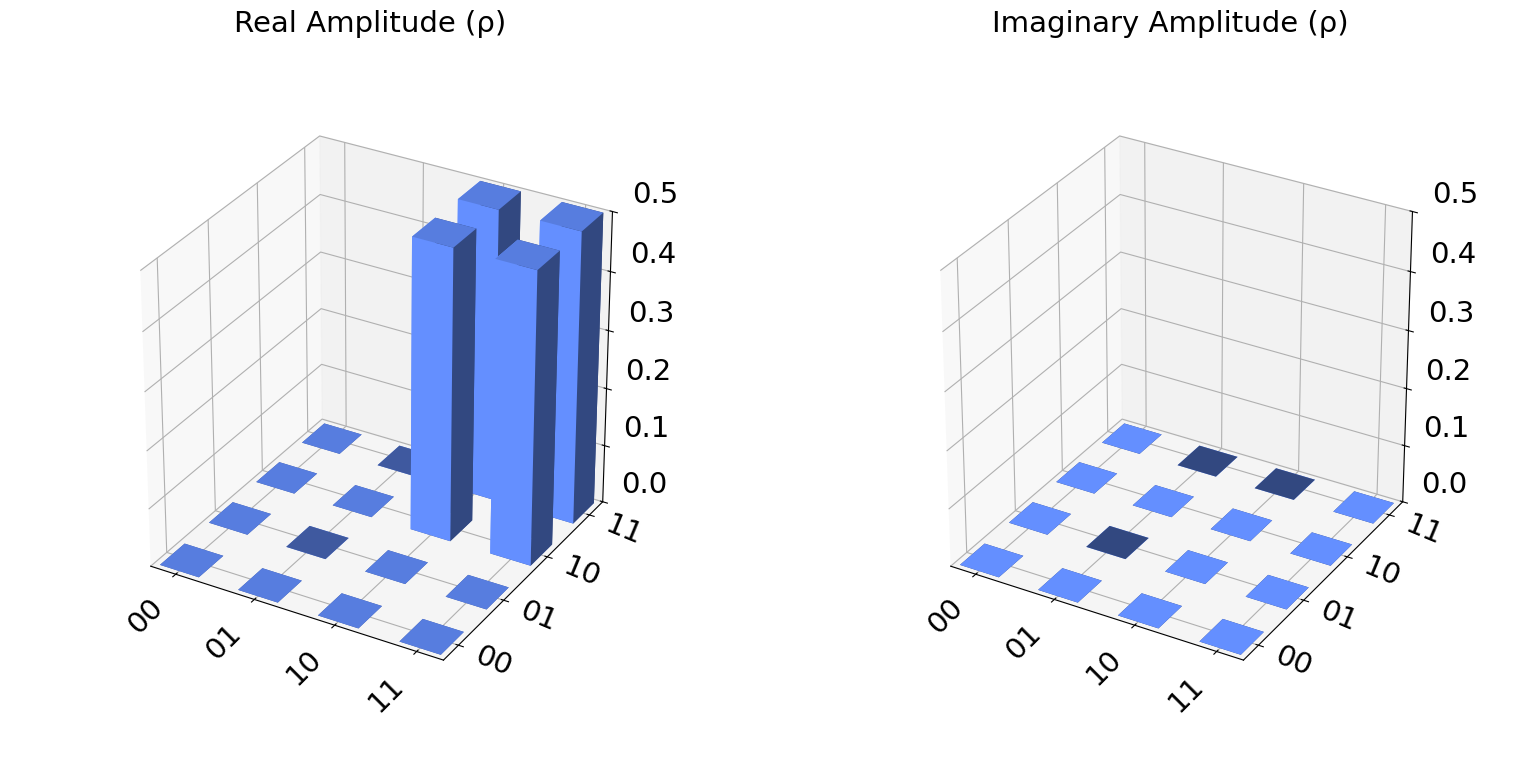

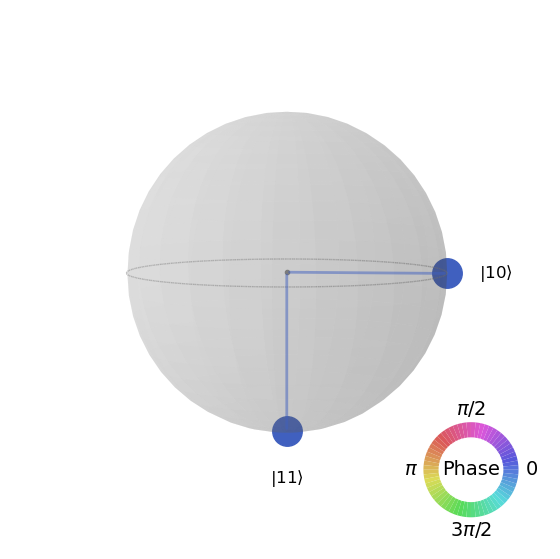

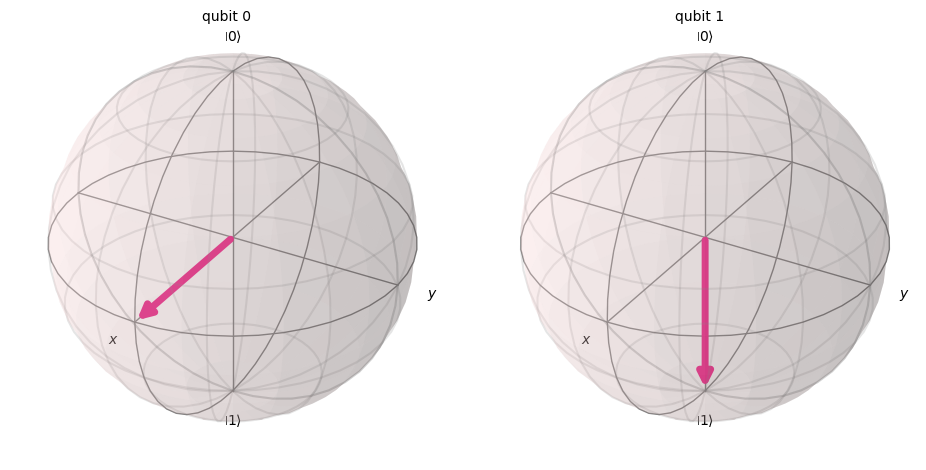

In [12]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import DensityMatrix
from qiskit.visualization import plot_state_city
from qiskit.visualization import plot_state_qsphere

 
qc = QuantumCircuit(2)
qc.h(0)
qc.x(1)
print(qc)
state = Statevector(qc)
print(state)
state.draw("latex")  # psi is a Statevector object
DensityMatrix(state).draw("latex")  # convert to a DensityMatrix and draw
state.draw("city")
state.draw("qsphere")
plot_bloch_multivector(state)

## 7. Important Single-Qubit Basis States

This section explores common single-qubit states:

- \(|+
angle\)
- \(|-
angle\)
- \(|+Y
angle\)
- \(|-Y
angle\)

These states are useful because they show how quantum information can be represented along different axes of the Bloch sphere. The activity helps students understand that qubits are not limited to only \(|0
angle\) and \(|1
angle\).

**Class activity:** Ask students to identify which gates move the qubit to the X-axis or Y-axis of the Bloch sphere.


In [9]:
 ##∣+⟩, ∣–⟩, ∣+Y⟩, and ∣–Y⟩,


from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import DensityMatrix
from qiskit.visualization import plot_state_city
from qiskit.visualization import plot_state_qsphere
import numpy as np

# Import Qiskit
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_state_city
import qiskit.quantum_info as qi
# Create a Quantum Circuit with one qubit
qc = QuantumCircuit(1)  # QuantumCircuit(num_qubits)

# |+⟩ state
qc.h(0)  # Apply Hadamard gate to qubit 0

# Draw the circuit
print("Circuit for |+⟩:")
print(qc)
simulator = AerSimulator()
# Simulate the circuit
job = simulator.run(qc, shots=100)

# Get the result
result = job.result()
state = Statevector(qc)
print(state)
state.draw("latex")  # psi is a Statevector object
#DensityMatrix(state).draw("latex")  # convert to a DensityMatrix and draw
#state.draw("city")
#state.draw("qsphere")
#plot_bloch_multivector(state)

# Reset the circuit for the next state
qc = QuantumCircuit(1)

# |−⟩ state
qc.x(0)  # Apply X gate to make |1⟩ state
qc.h(0)  # Apply Hadamard gate to qubit 0

# Draw the circuit
print("\nCircuit for |−⟩:")
print(qc)
job = simulator.run(qc, shots=100)

# Get the result
result = job.result()
state = Statevector(qc)
print(state)
state.draw("latex")  # psi is a Statevector object


qc = QuantumCircuit(1)
# |+Y⟩ state
qc.h(0)  # Apply Hadamard gate to qubit 0
qc.s(0)  # Apply Phase gate to qubit 0

# Draw the circuit
print("\nCircuit for |+Y⟩:")
print(qc)
job = simulator.run(qc, shots=100)

# Get the result
result = job.result()
state = Statevector(qc)
print(state)
state.draw("latex")  # psi is a Statevector object



# Reset the circuit for the next state
qc = QuantumCircuit(1)

# |−Y⟩ state
qc.x(0)  # Apply X gate to make |1⟩ state
qc.h(0)  # Apply Hadamard gate to qubit 0
qc.s(0)  # Apply Phase gate to qubit 0

# Draw the circuit
print("\nCircuit for |−Y⟩:")
print(qc)
job = simulator.run(qc, shots=100)

# Get the result
result = job.result()
state = Statevector(qc)
print(state)
state.draw("latex")  # psi is a Statevector object


Circuit for |+⟩:
   ┌───┐
q: ┤ H ├
   └───┘
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))

Circuit for |−⟩:
   ┌───┐┌───┐
q: ┤ X ├┤ H ├
   └───┘└───┘
Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))

Circuit for |+Y⟩:
   ┌───┐┌───┐
q: ┤ H ├┤ S ├
   └───┘└───┘
Statevector([0.70710678+0.j        , 0.        +0.70710678j],
            dims=(2,))

Circuit for |−Y⟩:
   ┌───┐┌───┐┌───┐
q: ┤ X ├┤ H ├┤ S ├
   └───┘└───┘└───┘
Statevector([0.70710678+0.j        , 0.        -0.70710678j],
            dims=(2,))


<IPython.core.display.Latex object>

## 8. Rotation Gates and Bloch Sphere Movement

This cell demonstrates how rotation gates change the position of a qubit state on the Bloch sphere. Rotation angles are converted from degrees to radians because Qiskit uses radians for rotation operations.

The example applies an `RY` rotation and then displays the resulting state vector and Bloch sphere position.

 Rotation gates are essential in quantum algorithms because they allow controlled movement of qubit states around the Bloch sphere.


Statevector([-0.70710678+0.j,  0.70710678+0.j],
            dims=(2,))


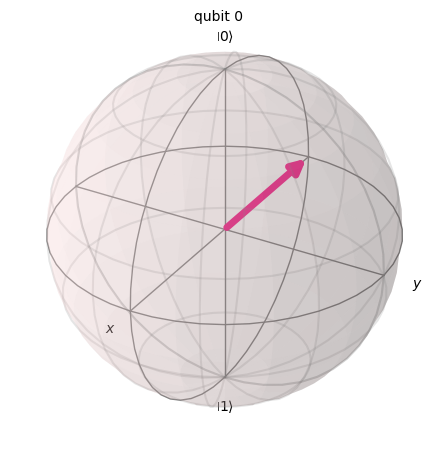

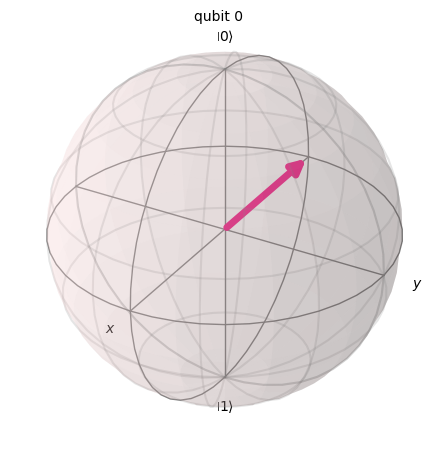

In [10]:
import numpy as np
%matplotlib inline
rotation_angle_x = np.deg2rad(270)  # Rotation angle around X-axis in radians
rotation_angle_y = np.deg2rad(90)  # Rotation angle around Y-axis in radians
rotation_angle_z = np.deg2rad(90) 
qc = QuantumCircuit(1)  # QuantumCircuit(num_qubits)

qc = QuantumCircuit(1)
qc.ry(rotation_angle_x, 0)
simulator = AerSimulator()
# Simulate the circuit
job = simulator.run(qc, shots=100)

# Get the result
result = job.result()
state = Statevector(qc)
print(state)
state.draw("latex")  # psi is a Statevector objectrotation_angle_y = 0.5  # Rotation angle in radians
plot_bloch_multivector(state)

## 9. Exporting a Circuit to QASM

This cell introduces QASM, a text-based representation of a quantum circuit. QASM is useful because it allows circuits to be saved, shared, inspected, and submitted to compatible quantum platforms.

The circuit creates a Bell state and measures both qubits. The printed QASM output shows the circuit instructions in a standard format.

 Students should recognise the relationship between Qiskit circuit commands and the generated QASM instructions.


In [11]:
import qiskit.qasm2
from qiskit.circuit import QuantumCircuit
 
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])
print(qiskit.qasm2.dumps(qc))

OPENQASM 2.0;
include "qelib1.inc";
qreg q[2];
creg c[2];
h q[0];
cx q[0],q[1];
measure q[0] -> c[0];
measure q[1] -> c[1];


## 10. Saving the QASM File

This cell saves the QASM representation of the circuit into a file called `myfile.qasm`.

This is useful when a circuit needs to be transferred to another environment, submitted to a device, or stored for later use.


In [15]:
qiskit.qasm2.dump(qc, "myfile.qasm")

## 11. Loading a QASM File Back into Qiskit

This cell loads the previously saved QASM file and reconstructs the quantum circuit in Qiskit.

This demonstrates that QASM can be used as an exchange format between different tools and workflows.



In [ ]:
import qiskit.qasm2
circuit = qiskit.qasm2.load("myfile.qasm")
print(circuit)

     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 


## 12. Preparing to Submit QASM to Quokka

This section imports required libraries and defines the current Quokka endpoint.

The purpose is to prepare a QASM script so it can be submitted to the Quokka quantum simulator/device interface.

This cell may require internet access and a working Quokka endpoint. If the endpoint is unavailable, the request cells may fail, but the teaching concept remains valid.


In [16]:
# the usual imports
import qiskit
import qiskit.qasm2
import numpy as np
import requests
import os
import json
#from google.colab import files

# current Quokka address:
req_str_qasm = 'http://quokka1.quokkacomputing.com/qsim/qasm'

## 13. Cleaning the QASM Script for Quokka

By default, Qiskit may include library instructions that are not supported by Quokka. This cell removes part of the QASM header so the script is compatible with the Quokka endpoint.

The cleaned script is printed so students can inspect exactly what will be submitted.

 Different quantum platforms may support different gate sets and QASM formats, so compatibility checking is important.


In [18]:
code = qiskit.qasm2.dumps(circuit)

# by default, qiskit includes a library of gates not installed on the Quokka
# this code removes that
code = code[:14] + code[(14 + 22):]

print(code)

OPENQASM 2.0;
qreg q1[4];
creg c1[4];
h q1[0];
h q1[1];
h q1[2];
h q1[3];
measure q1[0] -> c1[0];
measure q1[1] -> c1[1];
measure q1[2] -> c1[2];
measure q1[3] -> c1[3];


## 14. Sending the QASM Script to Quokka

This cell packages the QASM script into a JSON object and sends it to the Quokka endpoint using an HTTP POST request.

The returned JSON result contains the output generated by the remote service.

If this cell fails, discuss possible reasons such as internet access, endpoint availability, or script compatibility.


In [19]:
data = {
    'script': code,
    'count': 10
}

result = requests.post(req_str_qasm, json=data)
json_obj = json.loads(result.content)

print(json_obj)


{'error': 'no error', 'error_code': 0, 'result': {'c1': [[0, 1, 0, 0], [1, 1, 0, 1], [0, 1, 0, 1], [1, 0, 0, 0], [1, 0, 0, 0], [0, 0, 1, 0], [0, 1, 1, 1], [1, 1, 1, 1], [0, 0, 1, 0], [0, 1, 0, 1]]}}


## End of Notebook — Teaching Summary

Use the end of the class to summarise the main concepts:

- State vectors describe quantum states mathematically.
- Hadamard gates create superposition.
- Controlled gates such as CX can create entanglement.
- Measurement converts quantum information into classical bitstrings.
- Histograms and visualisations help interpret results.
- QASM supports circuit portability and device submission.
- Quantum outputs can be analysed statistically.

**Suggested student activity:** Ask students to modify one circuit, predict the result, run the simulation, and compare the prediction with the measured output.
